### Eddy Identification & Tracking

In [14]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from py_eddy_tracker.observations.tracking import TrackEddiesObservations

LON_RANGE = [-81, -56]
LAT_RANGE = [29, 44]
HIGHLIGHT = {"cyclone": 13, "anticyclone": 3}

In [15]:
tracks = {}
for pol in ("cyclone", "anticyclone"):
    path = ROOT / "outputs" / "gulf_stream_cyclonic" / "eddy_track" / pol / f"{pol}_tracks.zarr"
    t = TrackEddiesObservations.load_file(str(path))
    lons = t["longitude"].copy()
    lons[lons > 180] -= 360
    tracks[pol] = {"obs": t, "lon": lons, "lat": t["latitude"], "ids": np.unique(t["track"])}

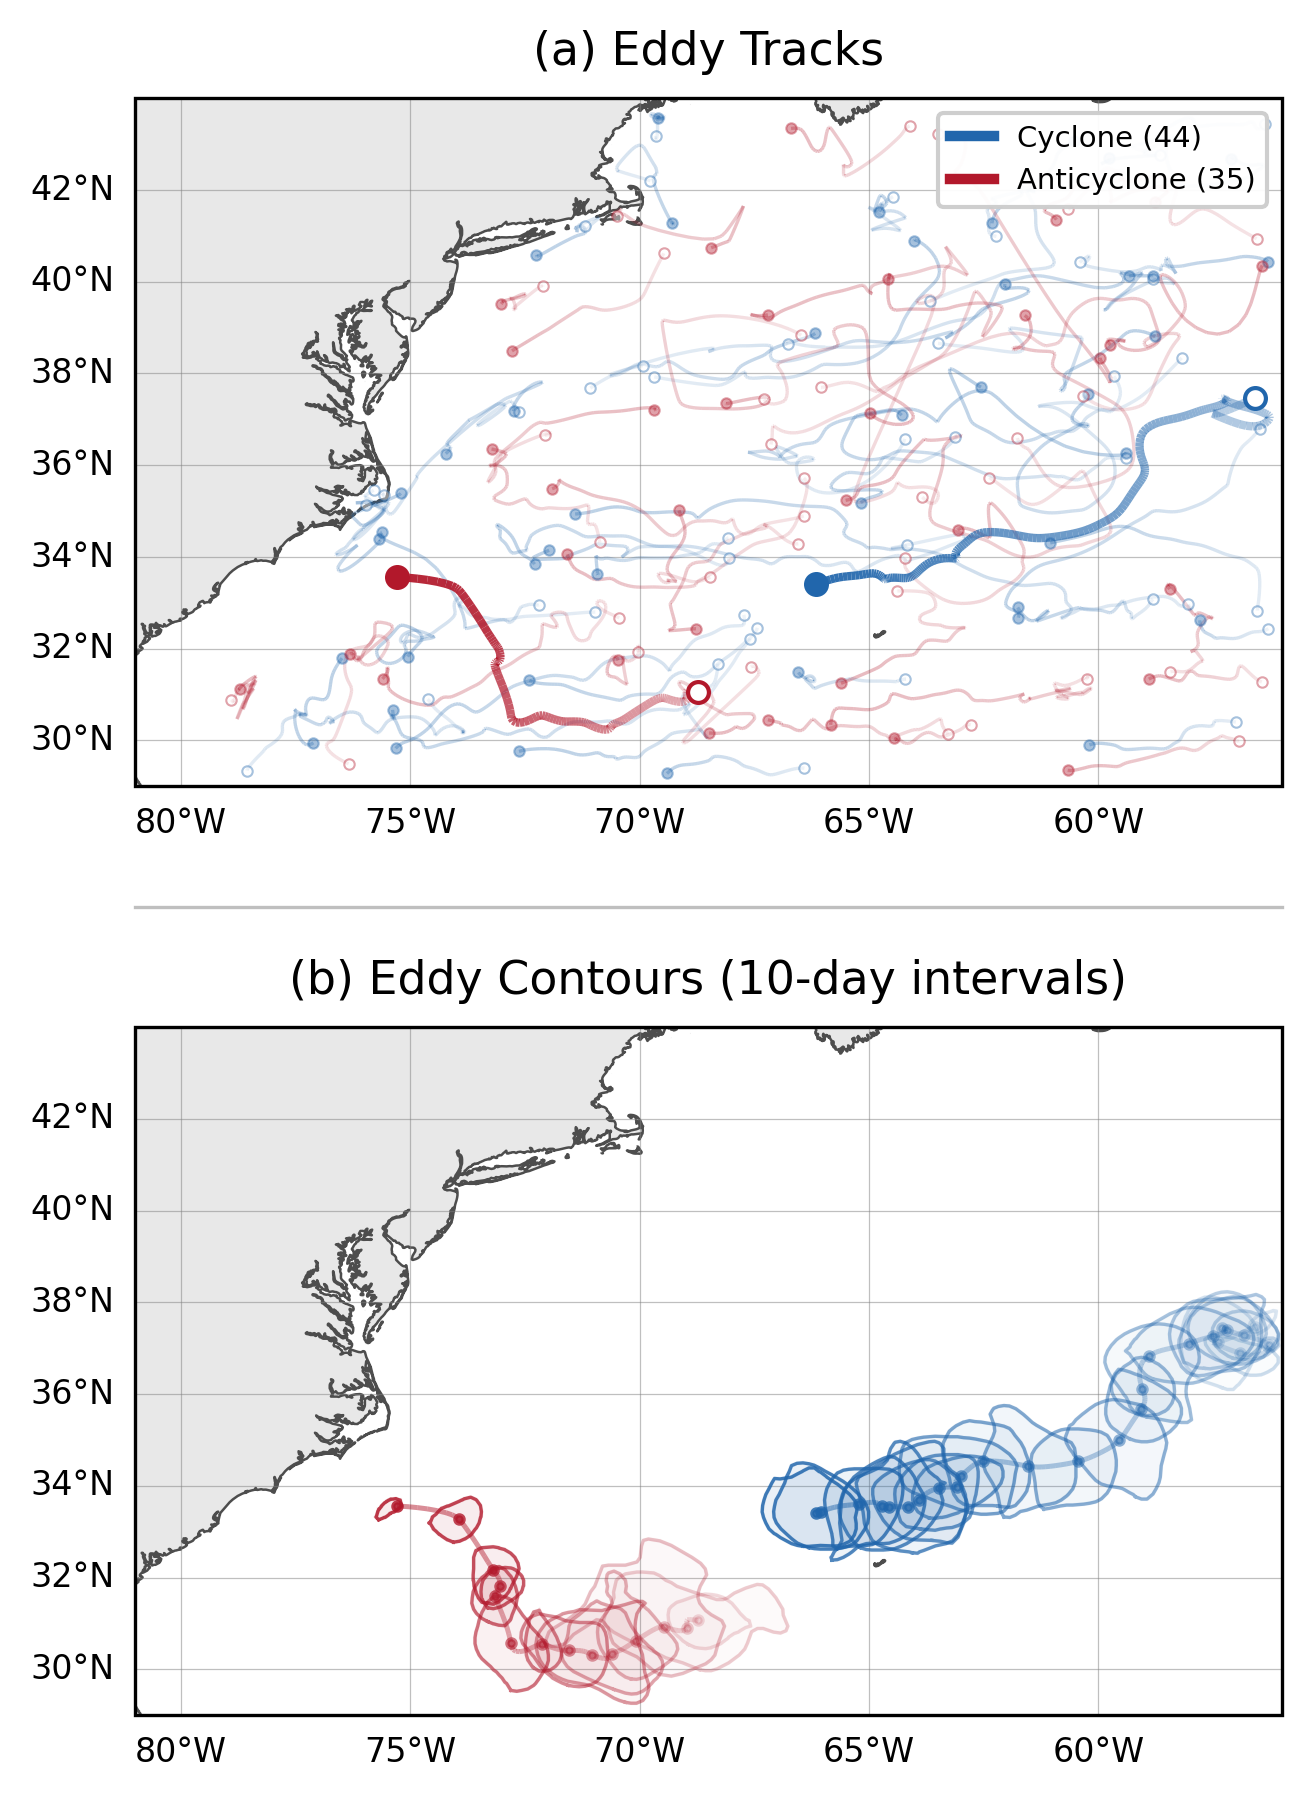

In [16]:
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection

COLORS = {"cyclone": "#2166ac", "anticyclone": "#b2182b"}

def gradient_track(ax, lons, lats, color, lw=2.5, alpha_range=(0.2, 0.95), zorder=6):
    points = np.array([lons, lats]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    n = len(segments)
    alphas = np.linspace(alpha_range[0], alpha_range[1], n)
    rgba = mcolors.to_rgba(color)
    colors = [(rgba[0], rgba[1], rgba[2], a) for a in alphas]
    ax.add_collection(LineCollection(segments, colors=colors, linewidths=lw, transform=proj, zorder=zorder))

proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(10, 7), dpi=300)
gs = fig.add_gridspec(2, 1, height_ratios=[1, 1], hspace=0.35)
ax1 = fig.add_subplot(gs[0], projection=proj)
ax2 = fig.add_subplot(gs[1], projection=proj)

for ax in (ax1, ax2):
    ax.set_extent([*LON_RANGE, *LAT_RANGE], crs=proj)
    ax.add_feature(cfeature.NaturalEarthFeature("physical", "land", "10m",
                   facecolor="#e8e8e8", edgecolor="none"), zorder=1)
    ax.add_feature(cfeature.NaturalEarthFeature("physical", "coastline", "10m",
                   facecolor="none", edgecolor="0.3", linewidth=0.6), zorder=2)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="0.5", alpha=0.5, zorder=4)
    gl.top_labels = gl.right_labels = False
    gl.xlabel_style = {"size": 8}
    gl.ylabel_style = {"size": 8}

# Panel A: all tracks with hollow start / filled end markers
for pol in ("cyclone", "anticyclone"):
    t = tracks[pol]
    hid = HIGHLIGHT[pol]
    color = COLORS[pol]
    for tid in t["ids"]:
        mask = t["obs"]["track"] == tid
        lx, ly = t["lon"][mask], t["lat"][mask]
        if tid != hid:
            gradient_track(ax1, lx, ly, color, lw=0.8, alpha_range=(0.12, 0.3), zorder=3)
            ax1.plot(lx[0], ly[0], "o", color=color, ms=2.5, mfc="white", mew=0.5,
                     alpha=0.4, transform=proj, zorder=4)
            ax1.plot(lx[-1], ly[-1], "o", color=color, ms=2.5, mfc=color, mew=0.5,
                     alpha=0.4, transform=proj, zorder=4)
        else:
            gradient_track(ax1, lx, ly, color, lw=2.0, alpha_range=(0.3, 0.95), zorder=6)
            ax1.plot(lx[0], ly[0], "o", color=color, ms=5, mfc="white", mew=1.0,
                     transform=proj, zorder=8)
            ax1.plot(lx[-1], ly[-1], "o", color=color, ms=5, mfc=color, mew=1.0,
                     transform=proj, zorder=8)

n_cyc = len(tracks["cyclone"]["ids"])
n_anti = len(tracks["anticyclone"]["ids"])
ax1.legend(handles=[
    plt.Line2D([], [], color=COLORS["cyclone"], lw=2.5, label=f"Cyclone ({n_cyc})"),
    plt.Line2D([], [], color=COLORS["anticyclone"], lw=2.5, label=f"Anticyclone ({n_anti})"),
], loc="upper right", fontsize=7, frameon=True, facecolor="white",
   edgecolor="0.8", framealpha=0.95, handlelength=1.5)
ax1.set_title("(a) Eddy Tracks", fontsize=11, pad=8)

# Panel B: contours with gradient, no arrows
for pol in ("cyclone", "anticyclone"):
    t_data = tracks[pol]["obs"]
    hid = HIGHLIGHT[pol]
    color = COLORS[pol]
    mask = t_data["track"] == hid
    indices = np.where(mask)[0]
    lx = tracks[pol]["lon"][mask]
    ly = tracks[pol]["lat"][mask]
    n_obs = len(indices)

    gradient_track(ax2, lx, ly, color, lw=1.2, alpha_range=(0.15, 0.5))

    contour_idx = list(range(0, n_obs, 10))
    if (n_obs - 1) not in contour_idx:
        contour_idx.append(n_obs - 1)
    n_c = len(contour_idx)

    for j, ci in enumerate(contour_idx):
        idx = indices[ci]
        clons = t_data["contour_lon_e"][idx].copy()
        clats = t_data["contour_lat_e"][idx].copy()
        clons[clons > 180] -= 360
        clons = np.append(clons, clons[0])
        clats = np.append(clats, clats[0])
        alpha = 0.15 + 0.7 * (j / max(n_c - 1, 1))
        ax2.plot(clons, clats, color=color, lw=0.8, alpha=alpha, transform=proj, zorder=5)
        ax2.fill(clons, clats, color=color, alpha=alpha * 0.1, transform=proj, zorder=4)
        ax2.plot(lx[ci], ly[ci], ".", color=color, ms=4, alpha=alpha, transform=proj, zorder=6)

ax2.set_title("(b) Eddy Contours (10-day intervals)", fontsize=11, pad=8)

# Match panel sizes
fig.canvas.draw()
pos1 = ax1.get_position()
pos2 = ax2.get_position()
ax2.set_position([pos1.x0, pos2.y0, pos1.width, pos1.height])

pos2_new = ax2.get_position()
mid_y = (pos1.y0 + pos2_new.y1) / 2
fig.add_artist(plt.Line2D([pos1.x0, pos1.x0 + pos1.width], [mid_y, mid_y],
               transform=fig.transFigure, color="0.75", linewidth=0.8))

fig.savefig("eddy_id_and_tracking.png", dpi=300, bbox_inches="tight")
plt.show()
